<a href="https://colab.research.google.com/github/prkalva10/Collab/blob/main/Aula_03_Analise_com_grafico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análise de dados do OLIST:
1. Tendencia de volume de pedidos ao longo do tempo;
2. Como é o custo médio do frete varia geograficamente e como isso afeta a compra;
3. Qual é o impacto da demora da entrega e quem é o culpado: lojista ou transportadora?

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_customers = pd.read_csv(path + '/olist_customers_dataset.csv')

In [ ]:
print(df_customers.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


In [ ]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
df_customers.sample()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
16867,da70cbcb5012f2055b4f2c90d28725fc,cf3ca218511c73ca4a1c6a19e71f02d4,37060,varginha,MG


In [ ]:
df_customers.sample(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
2021,1bf2f43d6cf4c045e9dcfd3b9a8cef53,a0da7b3e4040e0427f5880f11622ecb2,12062,taubate,SP
27117,1c0abb9215bf7e9bfb6af1330e66a8a7,d4c20e9ae28a09c90546e5c7e22f02b9,88045,florianopolis,SC
90064,324741283d4f00aa65cc54c106a5f35e,101b821e4487abb779ff92de7b7f6457,2317,sao paulo,SP
59849,881cde96227ba4ff44f52daa470b497a,a84ef2a637db68d83ae9c3ff6568a923,51111,recife,PE
97829,6f8553aa76c8c49117ba3d430475d732,cd2cd01a52c2e69287318ad08ea835ce,79550,costa rica,MS
44423,9ac3db974bf3b1f393ad46eb82c1adfb,61fa90fbaf8ae2ef37080c2f8acbd0f0,4618,sao paulo,SP
89544,174a247558b42728a22d8c5ee161c424,de311696c3796c4c962f71d8991c1ecd,1420,sao paulo,SP
2186,a7961e607552d0cebcc486ef283b4c47,3f0454458b119008c146b74030cb324a,12630,cachoeira paulista,SP
86999,18e81821d7e7326070a3cf464c4822bb,7afef6c55ae419bb971bf15c90c24104,8750,mogi das cruzes,SP
94945,4c561ffd312db62fc188efa729a06a0f,5e619209a456f600c58ffe4d1efebe45,11900,registro,SP


In [ ]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
df_customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [ ]:
# Forçar um tipo para leitura, o CEP será str e não int
df_customers = pd.read_csv(path + '/olist_customers_dataset.csv',
                           dtype = {'customer_zip_code_prefix':str})

In [ ]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
df_orders = pd.read_csv(path + '/olist_orders_dataset.csv')

In [ ]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
df_reviews = pd.read_csv(path + '/olist_order_reviews_dataset.csv')

In [ ]:
df_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


*   Média - sensível a extremos
*   Mediana - Comportamento real
*   Moda - O que mais se repete

In [ ]:
# exemplo de média e mediana
tempos = [5, 5, 7, 8, 30]
df_tempos = pd.DataFrame(tempos)
df_tempos.median()

,0
0,7.0


In [ ]:
df_tempos.describe()

,0
count,5.000000
mean,11.000000
std,10.700467
min,5.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,30.000000


**Mediana**: 50% dos seus dados estão abaixo e 50% dos seus dados estão acima

In [ ]:
# MODA: aquilo que mais se repete
df_tempos.mode()

,0
0,5


In [ ]:
#Média - note que valor fora do padrão eleva muito a média
df_tempos.mean()

,0
0,11.0


In [ ]:
# fim da explicação de média, mediana e moda

**VALUE_COUNTS**: contagem de quantas vezes aparece um valor

In [ ]:
df_orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Dados ausentes**: vazio <> zero <> NaN

In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
nulos_pct = df_reviews.isnull().mean() * 100
nulos_pct

,0
review_id,0.000000
order_id,0.000000
review_score,0.000000
review_comment_title,88.341530
review_comment_message,58.702532
review_creation_date,0.000000
review_answer_timestamp,0.000000


In [ ]:
## DUPLICADAS - CUIDADO COM AS DUPLICADAS
total_duplicadas = df_orders.duplicated().sum()
total_duplicadas

np.int64(0)

In [ ]:
total_dupl_order_id = df_orders.duplicated(subset='order_id').sum()
total_dupl_order_id

np.int64(0)

In [ ]:
## MITIGAÇÃO de duplicadas
# keep first (defaul)
# keep last
# keep False

### df_orders.drop_duplicates()

*   **MCAR**: dados ausentes, cliente acidentalmente pulou, não tem relação a satisfação;
*   **MAR**: cliente que compra produto mais barato são menos propensos a deixar avaliação. Ausencia relacionada ao preço
*   **MNAR**: clientes com experiência negativa não deixam avaliação.

Se avaliação é inferior a 5% e não tem padrão identificável, é seguro assumir MCAR e aplicar remoção simples (dropna). Acima disso é necessário investigar se é MAR ou MNAR.





In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
# dropar a coluna que não é importante
# O título da revisão tem mais de 80% em branco, dai é melhor remover

df_reviews = df_reviews.drop(columns=['review_comment_title','review_comment_message','review_creation_date','review_answer_timestamp'])

In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     99224 non-null  object
 1   order_id      99224 non-null  object
 2   review_score  99224 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.3+ MB


In [ ]:
df_items = pd.read_csv(path + '/olist_order_items_dataset.csv')
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
df_main = df_orders.merge(df_customers, on='customer_id', how='inner')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
 8   customer_unique_id             99441 non-null  object
 9   customer_zip_code_prefix       99441 non-null  object
 10  customer_city                  99441 non-null  object
 11  customer_state                 99441 non-null  object
dtypes: object(12)
memory usage: 9.1+ MB


In [ ]:
df_main = df_main.merge(df_items, on='order_id', how='inner')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   customer_unique_id             112650 non-null  object 
 9   customer_zip_code_prefix       112650 non-null  object 
 10  customer_city                  112650 non-null  object 
 11  customer_state                 112650 non-null  object 
 12  order_item_id                 

In [ ]:
# Nem todos tem avaliação, por isso é LEFT
df_main = df_main.merge(df_reviews, on='order_id', how='left')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   customer_id                    113314 non-null  object 
 2   order_status                   113314 non-null  object 
 3   order_purchase_timestamp       113314 non-null  object 
 4   order_approved_at              113299 non-null  object 
 5   order_delivered_carrier_date   112111 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  113314 non-null  object 
 8   customer_unique_id             113314 non-null  object 
 9   customer_zip_code_prefix       113314 non-null  object 
 10  customer_city                  113314 non-null  object 
 11  customer_state                 113314 non-null  object 
 12  order_item_id                 

In [ ]:
# Remover campos que não são mais mecessários
df_main = df_main.drop(columns=['customer_id'])
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   order_status                   113314 non-null  object 
 2   order_purchase_timestamp       113314 non-null  object 
 3   order_approved_at              113299 non-null  object 
 4   order_delivered_carrier_date   112111 non-null  object 
 5   order_delivered_customer_date  110839 non-null  object 
 6   order_estimated_delivery_date  113314 non-null  object 
 7   customer_unique_id             113314 non-null  object 
 8   customer_zip_code_prefix       113314 non-null  object 
 9   customer_city                  113314 non-null  object 
 10  customer_state                 113314 non-null  object 
 11  order_item_id                  113314 non-null  int64  
 12  product_id                    

In [ ]:
# Não queremos itens que não tenham sido avaliados
# Vamos remover as que não foram entregues

df_main = df_main[df_main['order_status'] == 'delivered']

In [ ]:
df_main['order_status'].value_counts()

,count
order_status,
delivered,110840


In [ ]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110840 entries, 0 to 113313
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110840 non-null  object 
 1   order_status                   110840 non-null  object 
 2   order_purchase_timestamp       110840 non-null  object 
 3   order_approved_at              110825 non-null  object 
 4   order_delivered_carrier_date   110838 non-null  object 
 5   order_delivered_customer_date  110832 non-null  object 
 6   order_estimated_delivery_date  110840 non-null  object 
 7   customer_unique_id             110840 non-null  object 
 8   customer_zip_code_prefix       110840 non-null  object 
 9   customer_city                  110840 non-null  object 
 10  customer_state                 110840 non-null  object 
 11  order_item_id                  110840 non-null  int64  
 12  product_id                     1108

In [ ]:
df_main['order_purchase_timestamp']

,order_purchase_timestamp
0,2017-10-02 10:56:33
1,2018-07-24 20:41:37
2,2018-08-08 08:38:49
3,2017-11-18 19:28:06
4,2018-02-13 21:18:39
...,...
113309,2018-02-06 12:58:58
113310,2017-08-27 14:46:43
113311,2018-01-08 21:28:27
113312,2018-01-08 21:28:27


In [ ]:
# Converter de Timestamp para DateTime
df_main['order_purchase_timestamp'] = pd.to_datetime(df_main['order_purchase_timestamp'], format='%Y-%m-%d %H:%M:%S')
df_main['order_purchase_timestamp']

,order_purchase_timestamp
0,2017-10-02 10:56:33
1,2018-07-24 20:41:37
2,2018-08-08 08:38:49
3,2017-11-18 19:28:06
4,2018-02-13 21:18:39
...,...
113309,2018-02-06 12:58:58
113310,2017-08-27 14:46:43
113311,2018-01-08 21:28:27
113312,2018-01-08 21:28:27


In [ ]:
df_main['ano_mes'] = df_main['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_main['ano_mes']

,ano_mes
0,2017-10
1,2018-07
2,2018-08
3,2017-11
4,2018-02
...,...
113309,2018-02
113310,2017-08
113311,2018-01
113312,2018-01


In [ ]:
pedidos_por_mes = df_main.groupby('ano_mes')['order_id'].count().reset_index()
pedidos_por_mes

,ano_mes,order_id
0,2016-09,3
1,2016-10,317
2,2016-12,1
3,2017-01,924
4,2017-02,1869
5,2017-03,2917
6,2017-04,2577
7,2017-05,4048
8,2017-06,3524
9,2017-07,4460


Text(0.5, 1.0, 'Volume de Pedidos ao Longo do Tempo')

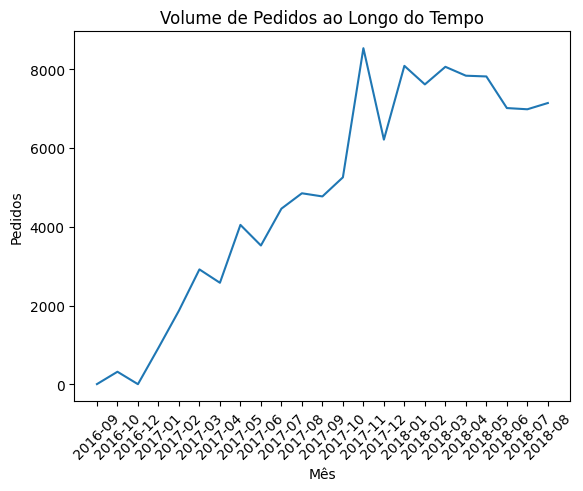

In [ ]:
import matplotlib.pyplot as plt
plt.plot(pedidos_por_mes['ano_mes'], pedidos_por_mes['order_id'])
plt.xlabel('Mês')
plt.xticks(rotation=45)
plt.ylabel('Pedidos')
plt.title('Volume de Pedidos ao Longo do Tempo')

Criado a FEATURE dias de espera

In [ ]:
# Conversão de timestamp para DateTime

df_main['order_delivered_customer_date'] = pd.to_datetime(
    df_main['order_delivered_customer_date'],
    format='%Y-%m-%d %H:%M:%S'
)
df_main['order_delivered_customer_date']

,order_delivered_customer_date
0,2017-10-10 21:25:13
1,2018-08-07 15:27:45
2,2018-08-17 18:06:29
3,2017-12-02 00:28:42
4,2018-02-16 18:17:02
...,...
113309,2018-02-28 17:37:56
113310,2017-09-21 11:24:17
113311,2018-01-25 23:32:54
113312,2018-01-25 23:32:54


In [ ]:
# Criação da colunas dias_espera

df_main['dias_espera'] = (df_main['order_delivered_customer_date'] - df_main['order_purchase_timestamp']).dt.days
df_main['dias_espera']

,dias_espera
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0
...,...
113309,22.0
113310,24.0
113311,17.0
113312,17.0


In [ ]:
df_main['dias_espera'].describe()

,dias_espera
count,110832.000000
mean,12.012036
std,9.445169
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


**OUTLIERS**: Bugs do sistema ou evento real raro



In [ ]:
# Tem entrega negativo?
bugs = df_main[df_main['dias_espera'] < 0]
print(f"Bugs, entregou antes de comprar??: {len(bugs)}")

Bugs, entregou antes de comprar??: 0


In [ ]:
# Demorou MUiTO
extremos = df_main[df_main['dias_espera'] > 150]
print(f"Atrasos Extremos: {len(extremos)}")

Atrasos Extremos: 27


In [ ]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110840 entries, 0 to 113313
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110840 non-null  object        
 1   order_status                   110840 non-null  object        
 2   order_purchase_timestamp       110840 non-null  datetime64[ns]
 3   order_approved_at              110825 non-null  object        
 4   order_delivered_carrier_date   110838 non-null  object        
 5   order_delivered_customer_date  110832 non-null  datetime64[ns]
 6   order_estimated_delivery_date  110840 non-null  object        
 7   customer_unique_id             110840 non-null  object        
 8   customer_zip_code_prefix       110840 non-null  object        
 9   customer_city                  110840 non-null  object        
 10  customer_state                 110840 non-null  object        
 11  order

In [ ]:
# Correlação entre dias de espera e avaliação

corr = df_main[['dias_espera', 'review_score']].corr()

<Axes: >

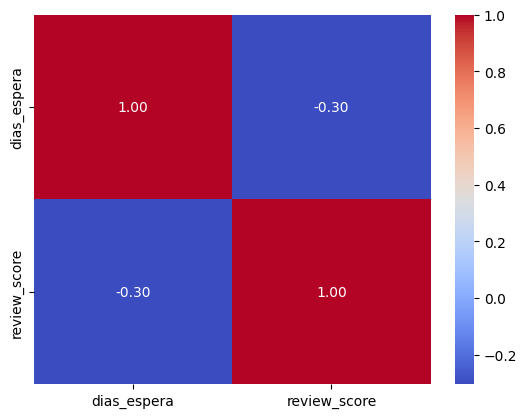

In [ ]:
import seaborn as sns

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

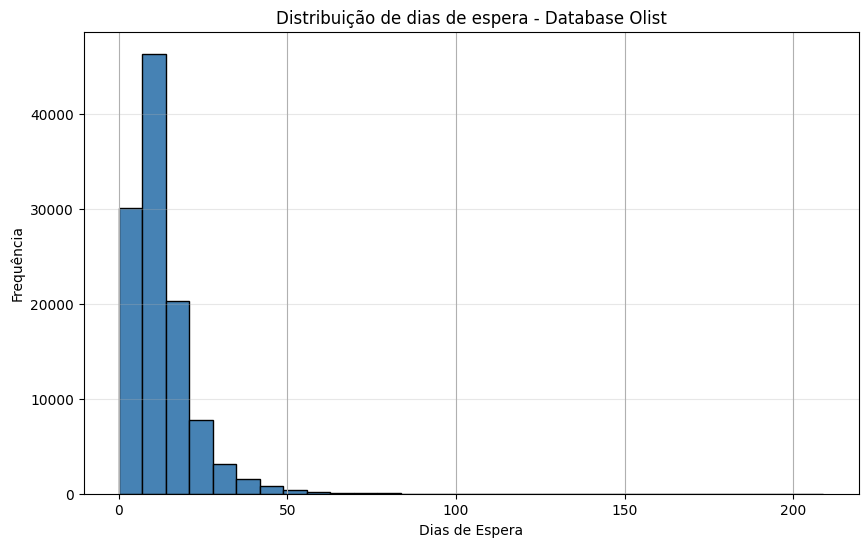

In [ ]:
# Distribuição de dias de espera
plt.figure(figsize=(10, 6))
df_main['dias_espera'].hist(bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Dias de Espera')
plt.ylabel('Frequência')
plt.title('Distribuição de dias de espera - Database Olist')
plt.grid(axis='y', alpha=0.3)
plt.show();